# Evaluation Metrics

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
RANDOM_STATE = 42

# Configure NumPy.
rng = np.random.default_rng(seed=RANDOM_STATE)
np.set_printoptions(linewidth=100)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Error

### 1.1 Introduction

#### Definition

Error is defined as the difference between target's actual value (in the dataset) and its prediction from a model. 

#### Formula

Error for single data-point can be calculated as:

$$
\large
\text{Error}\;=\;y^{(i)}\;-\;\hat{y}^{(i)}
$$

Errors are aggregated for the entire dataset as:

$$
\large
\text{Average Error}\;=\;\frac{1}{n}\,\sum_{i\,=\,1}^n\,\Bigl(y^{(i)}\;-\;\hat{y}^{(i)}\Bigr)
$$

#### Properties

- Error value is computed for each data-point.
- Error is how off the prediction - $\hat{y}$ - is from the actual target value $y$.
- Error for the complete dataset can be aggregated using average (a.k.a mean) operation.
- Always error-value must be smaller, hence **smaller the error-value better the model**.
- When aggregating, same error values of opposite signs can cancel out each other, hence we can take:
  - Absolute value of the difference in errors.
  - Squared value of the difference in errors.
- Error is also called as **Residuals** in Machine Learning.

### 1.2 Examples

In [3]:
def average_error(y_true, y_pred):
    """
    Function to calculate average error between
    y-true value and y-predicted values.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    avg_error = (y_true - y_pred).mean()

    return avg_error.round(2).item()

#### Example 1

In [4]:
y_true = [1, 2, 3, 4, 5]
y_pred = [1, 2, 3, 4, 5]  # Perfect predictions.
average_error(y_true, y_pred)

0.0

#### Example 2

In [5]:
y_true = [1.1, 1.2, 1.6, 1.4, 1.9]
y_pred = [1.2, 1.3, 1.4, 1.5, 1.8]  # Canceling errors.

average_error(y_true, y_pred)

0.0

## 2 Mean Absolute Error

### 2.1 Introduction

#### Formula

$$
\large
\mathrm{MAE}\;=\;\frac{1}{n}\sum_{i\,=\,0}^{n}\;\left|y^{(i)}\;-\;\hat{y}^{(i)}\right|
$$

#### Properties

- While aggregating errors, absolute value of the difference between the errors is considered.
- Smaller the MAE value better will be the model in predictions.
- MAE is **always greater than zero**, ranging between zero and infinity $[0,\;\infty)$.

#### Issues

- Absolute operation, $f(x) = \vert{x}\vert$ is not differentiable at $x = 0$.
- Instead of mod operator, difference between the errors can be squared while taking average.

#### API

In [6]:
from sklearn.metrics import mean_absolute_error

### 2.2 Examples

#### Example 1

In [7]:
y_true = [1, 2, 3, 4, 5]
y_pred = [1, 2, 3, 4, 5]  # Perfect predictions.
mean_absolute_error(y_true, y_pred)

0.0

#### Example 2

In [8]:
y_true = [1.1, 1.2, 1.6, 1.4, 1.9]
y_pred = [1.2, 1.3, 1.4, 1.5, 1.8]  # Canceling errors.

mae2 = mean_absolute_error(y_true, y_pred)
round(mae2, 2)

0.12

#### Example 3

In [9]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [100.2, 100.3, 100.4, 100.5, 100.6]

mae3 = mean_absolute_error(y_true, y_pred)
round(mae3, 2)

0.1

#### Example 4

In [10]:
y_true = [1.1, 1.2, 1.3, 1.4, 1.5]
y_pred = [2.2, 2.3, 2.4, 2.5, 2.6]

mae4 = mean_absolute_error(y_true, y_pred)
round(mae4, 2)

1.1

#### Example 5

In [11]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [200.2, 200.3, 200.4, 200.5, 200.6]

mae5 = mean_absolute_error(y_true, y_pred)
round(mae5, 2)

100.1

## 3 Mean Squared Error

### 3.1 Introduction

#### Formula

$$
\large
\mathrm{MSE}\;=\;\frac{1}{n}\sum_{i\,=\,0}^{n}\;\Bigl(y^{(i)}\;-\;\hat{y}^{(i)}\Bigr)^2
$$

#### Properties

- While aggregating errors, difference between the errors are squared.
- Smaller the MSE value better will be the model in predictions.
- MSE is **always greater than zero**, ranging between zero and infinity $[0,\;\infty)$.

#### Issues

- Squaring the error makes it hypersensitive and non-interpretable.
- Small differences are under-penalized and large differences are over-penalized.
- Therefore additionally compute squared-root of the mean squared error.

#### API

In [12]:
from sklearn.metrics import mean_squared_error

### 3.2 Examples

#### Example 1

In [13]:
y_true = [1, 2, 3, 4, 5]
y_pred = [1, 2, 3, 4, 5]  # Perfect predictions.
mean_squared_error(y_true, y_pred)

0.0

#### Example 2

In [14]:
y_true = [1.1, 1.2, 1.6, 1.4, 1.9]
y_pred = [1.2, 1.3, 1.4, 1.5, 1.8]  # Canceling errors.

mse2 = mean_squared_error(y_true, y_pred)
round(mse2, 2)

0.02

#### Example 3

In [15]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [100.2, 100.3, 100.4, 100.5, 100.6]

mse3 = mean_squared_error(y_true, y_pred)
round(mse3, 2)

0.01

#### Example 4

In [16]:
y_true = [1.1, 1.2, 1.3, 1.4, 1.5]
y_pred = [2.2, 2.3, 2.4, 2.5, 2.6]

mse4 = mean_squared_error(y_true, y_pred)
round(mse4, 2)

1.21

#### Example 5

In [17]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [200.2, 200.3, 200.4, 200.5, 200.6]

mse5 = mean_squared_error(y_true, y_pred)
round(mse5, 2)

10020.01

## 4 Root Mean Squared Error

### 4.1 Introduction

#### Formula

$$
\large
\mathrm{RMSE}\;=\;\sqrt{\frac{1}{n}\sum_{i\,=\,0}^{n}\;\Bigl(y^{(i)}\;-\;\hat{y}^{(i)}\Bigr)^2}
$$

#### Properties

- Smaller the RMSE value better will be the model in predictions.
- RMSE is **always greater than zero**, ranging between zero and infinity $[0,\;\infty)$.

#### Issues

- A single RMSE value, while evaluating performance of a single model, is not interpretable.

#### API

In [18]:
from sklearn.metrics import root_mean_squared_error

### 4.2 Examples

#### Example #1

In [19]:
y_true = [1, 2, 3, 4, 5]
y_pred = [1, 2, 3, 4, 5]  # Perfect predictions.
root_mean_squared_error(y_true, y_pred)

0.0

#### Example #2

In [20]:
y_true = [1.1, 1.2, 1.6, 1.4, 1.9]
y_pred = [1.2, 1.3, 1.4, 1.5, 1.8]  # Canceling errors.

rmse2 = root_mean_squared_error(y_true, y_pred)
round(rmse2, 2)

0.13

#### Example #3

In [21]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [100.2, 100.3, 100.4, 100.5, 100.6]

rmse3 = root_mean_squared_error(y_true, y_pred)
round(rmse3, 2)

0.1

#### Example #4

In [22]:
y_true = [1.1, 1.2, 1.3, 1.4, 1.5]
y_pred = [2.2, 2.3, 2.4, 2.5, 2.6]

rmse4 = root_mean_squared_error(y_true, y_pred)
round(rmse4, 2)

1.1

In [23]:
rmse_m1 = sum(y_true) / sum(y_pred)
round(rmse_m1, 2)

0.54

#### Example #5

In [24]:
y_true = [100.1, 100.2, 100.3, 100.4, 100.5]
y_pred = [200.2, 200.3, 200.4, 200.5, 200.6]

rmse5 = root_mean_squared_error(y_true, y_pred)
round(rmse5, 2)

100.1

In [25]:
rmse_m2 = sum(y_true) / sum(y_pred)
round(rmse_m2, 2)

0.5

#### Why RMSE is non-interpretable?

- A particular Model cannot be judged as good or bad solely based on its RMSE values.
- RMSE values say 900 vs 800, between Model #1 & Model #2 for example, indicates Model #2 is better because of its lower RMSE.
- RMSE values gets scaled differently for different models, depending on input features.
- Error ratios between Examples #4 and #5 are approximately same, but difference in their error values are very large.
  - Error ratios between Examples #4 and #5: 0.54 vs 0.5 respectively.
  - Error values between Examples #4 and #5: 1.1 vs 100.1 respectively.
- RMSE value obtained from training a single model is not interpretable. It cannot be used for checking goodness of fit.

## 5 R-Squared

### 5.1 Basic Prediction

#### Mean Baseline Prediction

- If predictions are to be made without building an ML model then the most basic prediction can be a **Mean Model**.
- Simplest prediction of any ML model is the average value of Target variable.
- When average of target value is used as prediction for every input feature vector its called as **Mean Baseline Prediction**.
- A **Mean Baseline Prediction** is a type of prediction where average of target value is used as prediction for every input feature vector.

#### Formula

$$
\large
\bar{y}\;=\;\frac{1}{n}\,\sum_{i\,=\,1}^n\,y^{(i)}
$$

Where,

- $n$ - Number of rows in the dataset.
- $y^{(i)}$ - Actual target value of $i^{\text{th}}$ feature vector.
- $\bar{y}$ - Average of all target values (Mean Baseline Prediction).

#### Example

##### Dataset

In [26]:
# Observed dataset.
X = np.array([0.9, 1.7, 2.5, 3.3, 4.1, 5.0, 6.2, 7.4, 8.6, 9.8])  # Feature.
y = np.array([9.97, 7.01, 7.79, 6.03, 5.02, 4.79, 3.65, 3.88, 0.97, 1.83])  # Target.

mbp = np.mean(y)
print("Mean Baseline Prediction:", mbp.item())

Mean Baseline Prediction: 5.093999999999999


##### Error

From above formula in topic 1.1, we already know that error (a.k.a residual) can be defined as:

$$
\large
\text{Error}\;=\;y^{(i)}\;-\;\hat{y}^{(i)}
$$

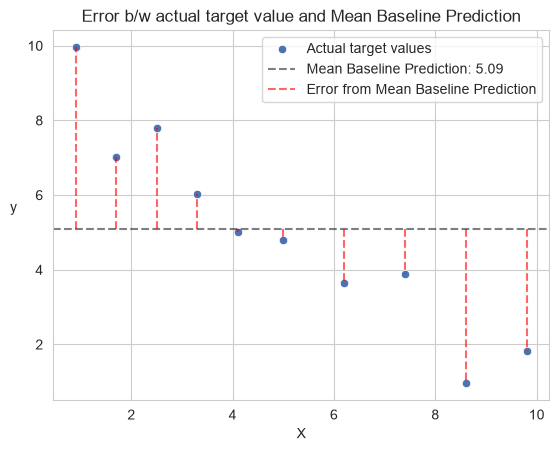

In [27]:
sns.scatterplot(x=X, y=y, label="Actual target values")
plt.axhline(y=mbp, color="k", linestyle="--", alpha=0.5, label=f"Mean Baseline Prediction: {mbp:.2f}")

print_once = lambda i: "Error from Mean Baseline Prediction" if i == 0 else None
for i, x in enumerate(X):
    plt.vlines(x, mbp, y[i], "r", "--", alpha=0.6, label=print_once(i))

plt.title("Error b/w actual target value and Mean Baseline Prediction")
plt.xlabel("X")
plt.ylabel("y", rotation=0, labelpad=10)
plt.legend()

plt.show()

### 5.2 Total Squared Error

#### Variance in Target

Variance in Target variable can be calculated as:

$$
\large
\sigma_y^2\;=\;\frac{1}{n}\,\sum_{i\,=\,1}^n\,\Bigl(y^{(i)}\;-\;\bar{y}\Bigr)^2
$$

Where,

- $\sigma_y^2$ - Variance is Target
- $n$ - Number of rows in the dataset.
- $y^{(i)}$ - Actual target value of $i^{\text{th}}$ feature vector.
- $\bar{y}$ - Average of all target values (Mean Baseline Prediction).

#### Total-Sum-of-Squared (TSS)

Deriving Total Squared Error a.k.a Total-Sum-of-Squared (TSS) error based on variance in Target using Mean-Baseline-Prediction. 

#### Formula

$$
\large
\text{Total Squared Error}\;=\;\sum_{i\,=\,1}^n\,\Bigl(y^{(i)}\;-\;\bar{y}\Bigr)^2
$$

Where,

- $n$ - Number of rows in the dataset.
- $y^{(i)}$ - Actual target value of $i^{\text{th}}$ feature vector.
- $\bar{y}$ - Average of all target values (Mean Baseline Prediction).

#### Properties

- Formula of Total-Sum-of-Squared is similar to **Variance** (without normalizing factor).
- **Total Squared Error** is trying to **replicate the total variance in the Target** variable $y$.

### 5.3 Residual

An error a.k.a residual is the difference between observed value in dataset and predicted value from a model.

$$
\large
\begin{aligned}
\text{Residual}&\;=\;\text{Observed Value}\;-\;\text{Predicted Value} \\[10pt]
               &\;=\;y_i                  \;-\;\hat{y}_i
\end{aligned}
$$

#### Properties

- A residual is the vertical distance between the target's actual value and its predicted value on a regression line.
- When $x$ is able to exactly predict $y$ (using some mathematical equation $\hat{y}\;=\;f(x)$) the residuals will be zero.

#### Example

##### Dataset

In [28]:
# Observed dataset.
X = np.array([0.9, 1.7, 2.5, 3.3, 4.1, 5.0, 6.2, 7.4, 8.6, 9.8])  # Feature.
y_true = np.array([9.97, 7.01, 7.79, 6.03, 5.02, 4.79, 3.65, 3.88, 0.97, 1.83])  # Target.

##### Train a Model

In [29]:
m, c = np.polyfit(X, y_true, 1)

# Model predictions.
y_pred = m * X + c
y_pred

array([8.58849985, 7.89822827, 7.2079567 , 6.51768512, 5.82741355, 5.05085803, 4.01545067,
       2.9800433 , 1.94463594, 0.90922858])

In [30]:
mbp = np.mean(y_true)
print("Mean Baseline Prediction:", mbp.item())

Mean Baseline Prediction: 5.093999999999999


##### Residuals

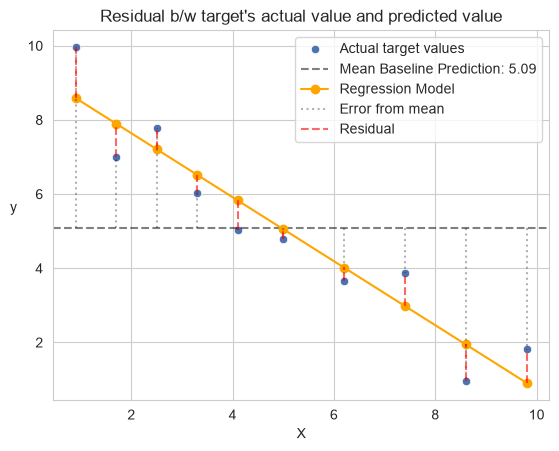

In [31]:
sns.scatterplot(x=X, y=y_true, label="Actual target values")
plt.axhline(y=mbp, color="k", linestyle="--", alpha=0.5, label=f"Mean Baseline Prediction: {mbp:.2f}")
plt.plot(X, y_pred, marker="o", color="orange", label="Regression Model")

print_once = lambda i, txt: txt if i == 0 else None
for i, x in enumerate(X):
    plt.vlines(x, mbp, y_true[i], "k", ":", alpha=0.3, label=print_once(i, "Error from mean"))
    ymin, ymax = min(y_true[i], y_pred[i]), max(y_true[i], y_pred[i])
    plt.vlines(x, ymin, ymax, "r", "--", alpha=0.6, label=print_once(i, "Residual"))

plt.title("Residual b/w target's actual value and predicted value")
plt.xlabel("X")
plt.ylabel("y", rotation=0, labelpad=10)
plt.legend()

plt.show()

### 5.4 Residual Squared Error

#### Residual-Sum-of-Squared (RSS)

Deriving Residual Squared Error a.k.a Residual-Sum-of-Squared (RSS) error based on errors in predictions.

#### Formula

$$
\large
\text{Residual Squared Error}\;=\;\sum_{i\,=\,1}^n\,\Bigl(y^{(i)}\;-\;\hat{y}^{(i)}\Bigr)^2
$$

Where,

- $n$ - Number of rows in the dataset.
- $y^{(i)}$ - Actual target value of $i^{\text{th}}$ feature vector.
- $\hat{y}^{(i)}$ - Predicted target value of $i^{\text{th}}$ feature vector.

#### Properties

- While **TSS** is calculated for **Mean Baseline Model**, **RSS** is calculated for **models trained on dataset**.
- When a trained model is better than Mean Baseline Model, RSS value will be less than TSS value.

### 5.5 Derivation of R-Squared

#### 1 Total Sum of Squared

$$
\large
\mathrm{SS}_\text{tot}\;=\;\sum_{i\,=\,1}^n\,\bigl(y_i\;-\;\bar{y}\bigr)^2
$$

- Calculating sum of squared error between each $y_i$ and $\bar{y}$.
- **TSS** is trying to capture the total variance in True Target values $y$.
- TSS is measuring the errors in the base model (mean baseline model).

#### 2 Residual Sum of Squared

$$
\large
\mathrm{SS}_\text{res}\;=\;\sum_{i\,=\,1}^n\,\bigl(y_i\;-\;\hat{y}_i\bigr)^2
$$

- Calculating sum of squared error between each $y_i$ and $\hat{y}_i$.
- **RSS** is trying to capture the variance in Residuals: $y\,-\,\hat{y}$.
- RSS captures the "left out variance" after training a model.
- RSS is measuring the errors in the newly trained model.

#### 3 Proportion

$$
\large
\begin{aligned}
\text{Proportion}&\;=\;\frac{\text{Residual variance in $\hat{y}$}}{\text{Total variance in $y$}} \\[10pt]
                 &\;=\;\frac{\mathrm{SS}_\text{res}}{\mathrm{SS}_\text{tot}}
\end{aligned}
$$


- Denominator captures the total variation in $y$.
- Numerator captures the left out variance in $y$.
- Therefore the ratio measures the proportion of variance in $y$ **failed to capture** by the trained model.

##### How to interpret Proportion?

- Proportion measures the failure of the model to capture the variance in residuals.
- When Proportion is say:
  - 0% - Model did not miss to capture any variance in $\hat{y}$.
  - 20% - Model missed to capture 20% of variance in $\hat{y}$.
  - 100% - Model missed to capture 100% of variance in $\hat{y}$ i.e., RSS and TSS are same.
- To convert this ratio of failure into ratio of success perform $1\,-\,\text{Proportion}$.
- Therefore $(1\,-\,\text{Proportion})$ is called as - $R^2$ - R-squared.

#### 4 R-Squared

$$
\large
\begin{aligned}
\text{R}^2\;&=\;1\;-\;\text{Proportion} \\[8pt]
            &=\;1\;-\;\frac{\mathrm{SS}_\text{res}}{\mathrm{SS}_\text{tot}}
\end{aligned}
$$

### 5.6 R-Squared Score

#### Definition

R-squared is the proportion of the total variation in the target variable $y$ accounted for by a fitted regression model using the independent variable(s) $X$, relative to predicting the mean of $y$.

#### What is R-Squared?

- R-squared is proportion or percentage of **variance** in $y$ **successfully captured** using $X$.
- R-squared value is a measurement of **Goodness of fit**.
- R-squared value is also called as **Coefficient of Determination**.
- R-squared value can not be considered as accuracy of the model.

#### Formula

$$
\large
\text{R}^2\;=\;1\;-\;\frac{\mathrm{SS}_\text{res}}{\mathrm{SS}_\text{tot}}
$$

#### Properties

- Model performances among multiple models can be compared using MAE, MSE or RMSE.
- Unlike MAE, MSE or RMSE, which are measuring errors, R-squared is measuring performance.
- R-squared is used to evaluate the performance of a single model.
- RSS error must be smaller than TSS error if it has to be better than Mean baseline model.
- R-squared is **always less than or equal to one**, ranging between minus infinity and one $(-\infty,\,1]$.

#### How to interpret R-Squared?

- Proportion measures amount of variance failed to capture, R-squared measures amount of variance captured by the model.
- When R-squared is say:
  - 0.0 - Model did not capture any variance in $\hat{y}$.
  - 0.2 - Model captured 20% of variance in $\hat{y}$.
  - 1.0 - Model captured 100% of variance in $\hat{y}$. RSS value will be zero, making it a perfect Model.
- When R-squared value is:
  - Less than zero, its considered as **"worst model"** since its performance is **below mean baseline model**.
  - Greater than but close to 0.0, its considered as **"bad model"** since its performance is **same as mean baseline model**.
  - Closer to 1 say greater than 0.8, its considered as **"good model"** since it is able to capture 80% of variance in residuals.

#### Issues

- R-squared score keeps on increasing as we include more and more features in model training.
- R-squared does not decrease even when including useless features and this is very misleading.

#### API

In [32]:
from sklearn.metrics import r2_score

### 5.7 Examples

#### Example #1

In [33]:
y_true = [0.83, 1.07, 2.98, 3.55, 4.79, 5.62, 6.14, 7.46, 8.31, 9.27]
y_pred = [0.74, 2.10, 3.17, 3.71, 4.28, 5.28, 6.49, 7.72, 8.49, 8.91]

print(f"R-Squared score: {r2_score(y_true, y_pred):.6f}")

R-Squared score: 0.975541


## 6 Adjusted R-squared

### 6.1 Introduction

#### Formula

$$
\newcommand{\p}{\bigl(1\;-\;R^2\bigr)\cdot\Biggl(\frac{n\;-\;1}{n\;-\;d\;-\;1}\Biggr)}
\large
\bar{R}^2\;=\;1\;-\;\Biggl[\,\p\,\Biggr]
$$

Where,

- $R^2$ - Ordinary R-squared score
- $n$ - Total number of observations (rows in the dataset)
- $d$ - Total number of predictors (columns in the dataset)

$$
\large
\text{As,}\quad{d}\,\uparrow\quad\bar{R}^2\,\downarrow
$$

#### Properties

- Adjusted R-squared score accounts for the number of predictors in the model.
- As $d$ increases, denominator decreases, the ratio increases resulting in decreases on Adjusted R-squared.
- Adjusted R-squared value can range between $(-\infty,\,1]$
- Higher Adjusted R-squared value indicates that regression model explains more variance in the dependent/target variable.

#### Issues

#### Custom Implementation

In [34]:
def adjusted_r2_score(r2_score: float, n: int, d: int) -> float:
    """
    Function to calculate adjusted r-squared score.
    """
    return 1 - ((1 - r2_score) * (n - 1) / (n - d - 1))

### 6.2 Examples

#### Example #1

## 7 Summary

<div style="display: inline-block">

|   # | Metric    |           Range |
| --: | :-------- | --------------: |
|   1 | MAE       |  $[0,\;\infty)$ |
|   2 | MSE       |  $[0,\;\infty)$ |
|   3 | RMSE      |  $[0,\;\infty)$ |
|   4 | R-squared | $(-\infty,\,1]$ |

</div>